<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
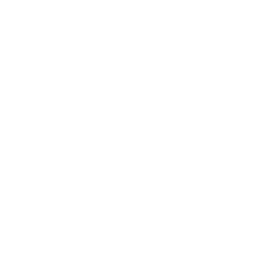
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Latin Square Design for Crop Variety Evaluation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Agriculture / Field Trial Design &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A 5x5 Latin square field trial compares five wheat varieties (ATLAS, BEACON, CREST, DELTA, ENVOY) while controlling two spatial nuisance gradients at once: row position and column position. The square is replicated 20 times for a 500-plot trial, and PROC GLM partitions yield variation into variety, row, and column effects using Type III sums of squares.

Every term is significant once the design is fit. Row position carries a real north-south fertility gradient (F = 9.31, p < .0001) and, at this sample size, the east-west column gradient is significant too (F = 6.40, p < .0001), so both blocking directions earn their place in the model. The variety effect is strong and unambiguous (F = 17.45, p < .0001). The model explains 21.4% of yield variance (R-square 0.2140, adjusted 0.1947, root MSE 3.82 bu/ac); the residual 79% is plot-to-plot and replicate-to-replicate noise the blocks cannot remove.

LSMEANS rank ATLAS highest (64.60 bu/ac) and CREST lowest (60.48 bu/ac), each with standard error 0.38. Under Tukey-adjusted pairwise comparisons ATLAS significantly outyields BEACON, CREST, and ENVOY (all adjusted p < .0001), and DELTA outyields CREST (p < .0001) and ENVOY (p = 0.0172); ATLAS and DELTA, the two leaders, are not distinguishable (adjusted p = 0.16). Residual diagnostics (Shapiro-Wilk p = 0.43, Anderson-Darling p = 0.15) support the normality assumption behind the F-tests.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------:|
| WORK.FIELD_TRIAL | Synthetic yield from a 5x5 Latin square (5 varieties balanced across 5 row and 5 column positions), the square replicated 20 times | 500 |

Each variety appears exactly once per row position and once per column position within each replicate, so the 500 plots hold a perfectly balanced design: 100 plots per variety, 100 per row block, 100 per column block (20 plots in every variety-by-row and row-by-column cell).

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Latin square field trial data
   5 varieties x 5 rows x 5 columns x 20 replicates = 500 plots
   -------------------------------------------------------- */
data work.field_trial;
    call streaminit(42);
    /* Latin square assignment matrix (5x5) */
    array lsq[5, 5] _temporary_ (
        1 2 3 4 5,
        2 3 4 5 1,
        3 4 5 1 2,
        4 5 1 2 3,
        5 1 2 3 4
    );
    array variety_names[5] $12 _temporary_ ('ATLAS' 'BEACON' 'CREST' 'DELTA' 'ENVOY');
    array variety_effects[5] _temporary_ (2.5 0 -1.2 1.8 -0.5);
    trial_id = 0;
    do replicate = 1 to 20;
        rep_effect = rand('normal', 0, 1.5);
        do row_pos = 1 to 5;
            row_effect = (row_pos - 3) * 0.8 + rand('normal', 0, 0.3);
            do col_pos = 1 to 5;
                trial_id + 1;
                col_effect = (col_pos - 3) * 0.5 + rand('normal', 0, 0.3);
                variety_idx = lsq[row_pos, col_pos];
                variety = variety_names[variety_idx];
                row_block = cat('R', put(row_pos, 1.));
                col_block = cat('C', put(col_pos, 1.));
                /* Yield in bushels per acre */
                yield_bpa = round(
                    62 + variety_effects[variety_idx]
                    + row_effect + col_effect + rep_effect
                    + rand('normal', 0, 3.5), 0.1);
                if yield_bpa < 30 then yield_bpa = 30;
                soil_moisture = round(rand('normal', 22, 3), 0.1);
                output;
            end;
        end;
    end;
    drop variety_idx variety_effects1-variety_effects5 rep_effect
         row_effect col_effect;
run;

NOTE: DATA work.field_trial


NOTE: Wrote work.field_trial (500 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

                                                  The MEANS Procedure

                                             Analysis Variable : yield_bpa

        variety           N Obs           Mean        Std Dev
        -----------------------------------------------------
        ATLAS               100     64.6020000      4.3050588
        BEACON              100     61.9380000      3.6292243
        CREST               100     60.4830000      3.9953269
        DELTA               100     63.3770000      3.9052375
        ENVOY               100     61.7010000      4.2497176
        -----------------------------------------------------

                                           Analysis Variable : soil_moisture

        variety           N Obs           Mean        Std Dev
        -----------------------------------------------------
        ATLAS               100     21.8320000      2.9517288
        BEACON              100     22.5660000      2.7812583
        CREST               10

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_variety_row_block.spec.json
NOTE: ODS plot written: freq_mosaic_row_block_col_block.spec.json
NOTE: PROC FREQ statement used.


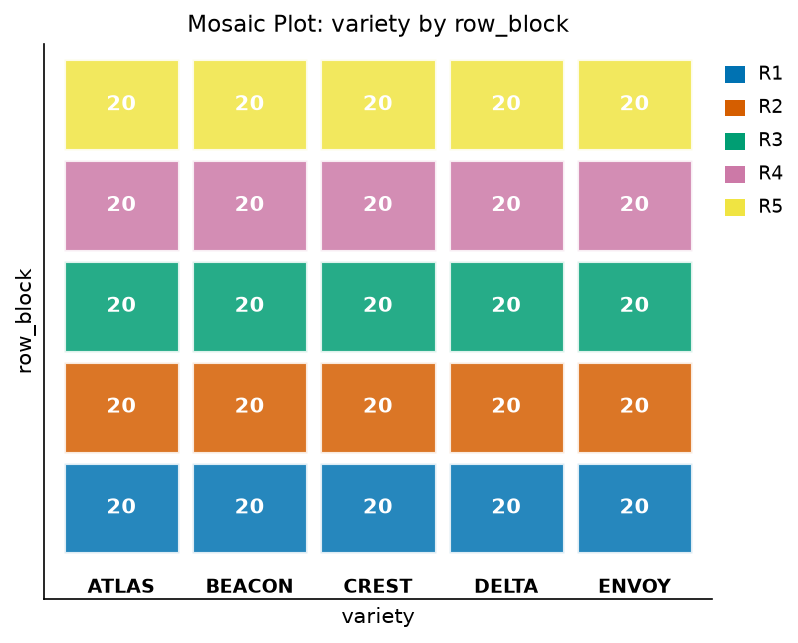

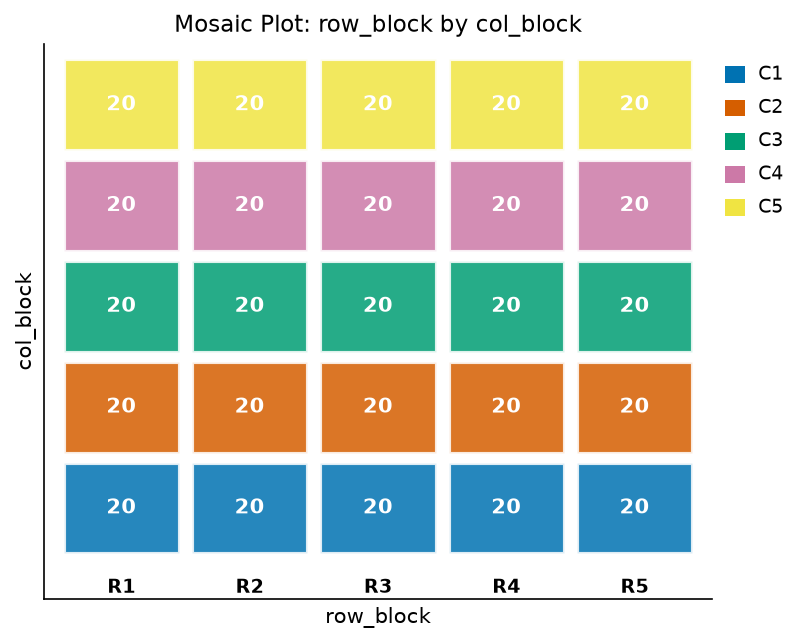

In [2]:
/* --------------------------------------------------------
   Baseline: yield summary by variety and blocking factors
   -------------------------------------------------------- */
proc means data=work.field_trial n mean std;
    class variety;
    var yield_bpa soil_moisture;
run;

proc freq data=work.field_trial;
    tables variety * row_block * col_block / norow nocol nopercent;
run;

---

NOTE: PROC SGPLOT data=work.field_trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


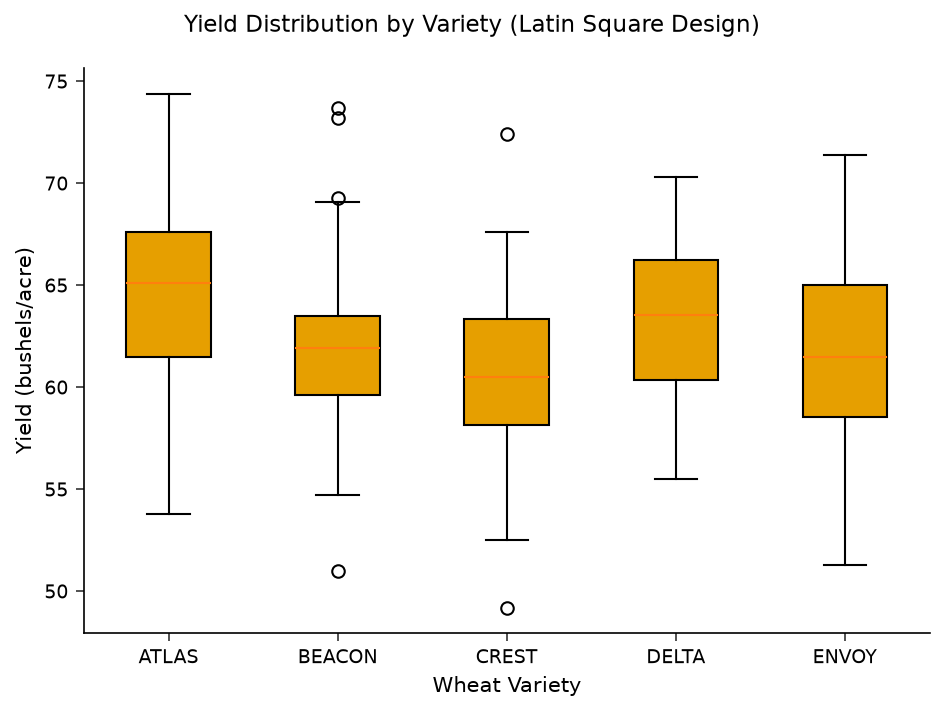

In [3]:
/* --------------------------------------------------------
   Yield by variety with blocking structure overlay
   -------------------------------------------------------- */
proc sgplot data=work.field_trial;
    vbox yield_bpa / category=variety;
    xaxis label='Wheat Variety';
    yaxis label='Yield (bushels/acre)';
    title 'Yield Distribution by Variety (Latin Square Design)';
run;

---

                         The GLM Procedure                          
                   Dependent Variable: yield_bpa                    

Source           DF  Sum of Squares  Mean Square   F Value    Pr > F
---------  --------  --------------  -----------  --------  --------
variety           4      1017.82268    254.45567     17.45    <.0001
row_block         4       542.81308    135.70327      9.31    <.0001
col_block         4       373.16828     93.29207      6.40    <.0001
Error           487      7100.88194     14.58087                    

Root MSE           3.81849    R-Square            0.2140
Adj R-Sq            0.1947

           Least Squares Means for variety            

Level       LSMean  Standard Error  Lower CL  Upper CL
--------  --------  --------------  --------  --------
ATLAS      64.6020          0.3818   63.8517   65.3523
BEACON     61.9380          0.3818   61.1877   62.6883
CREST      60.4830          0.3818   59.7327   61.2333
DELTA      63.3770          0.

NOTE: PROC GLM data=work.field_trial

NOTE: OUTPUT dataset written to: ./work/022b88c7-0c81-4e6a-bd44-b2b6b2ada4c0/trial_residuals.avro
NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_variety.spec.json
NOTE: ODS plot written: glm_lsmeans_variety.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


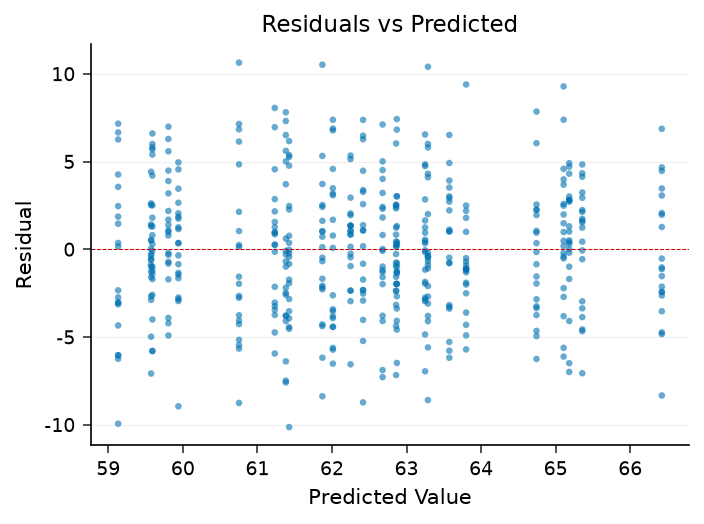

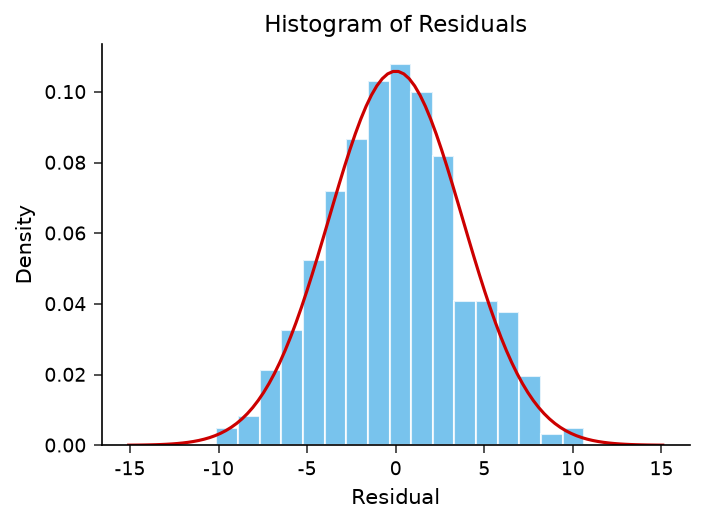

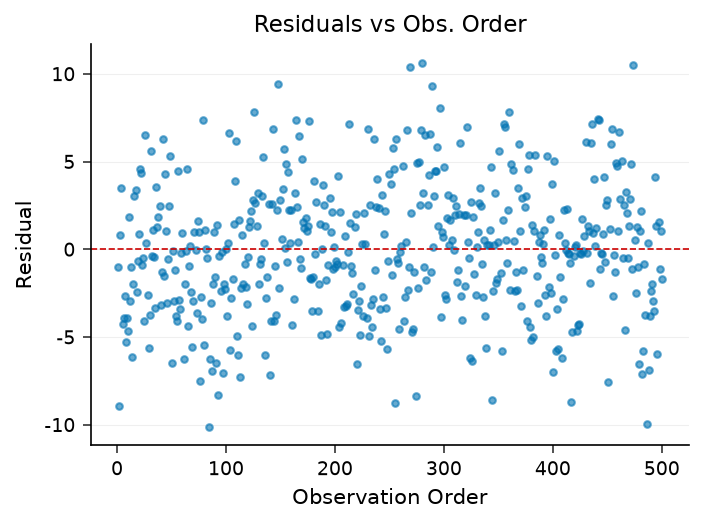

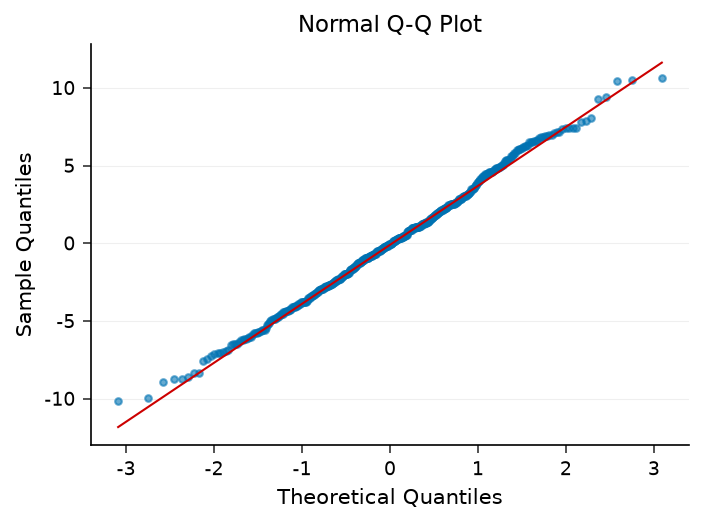

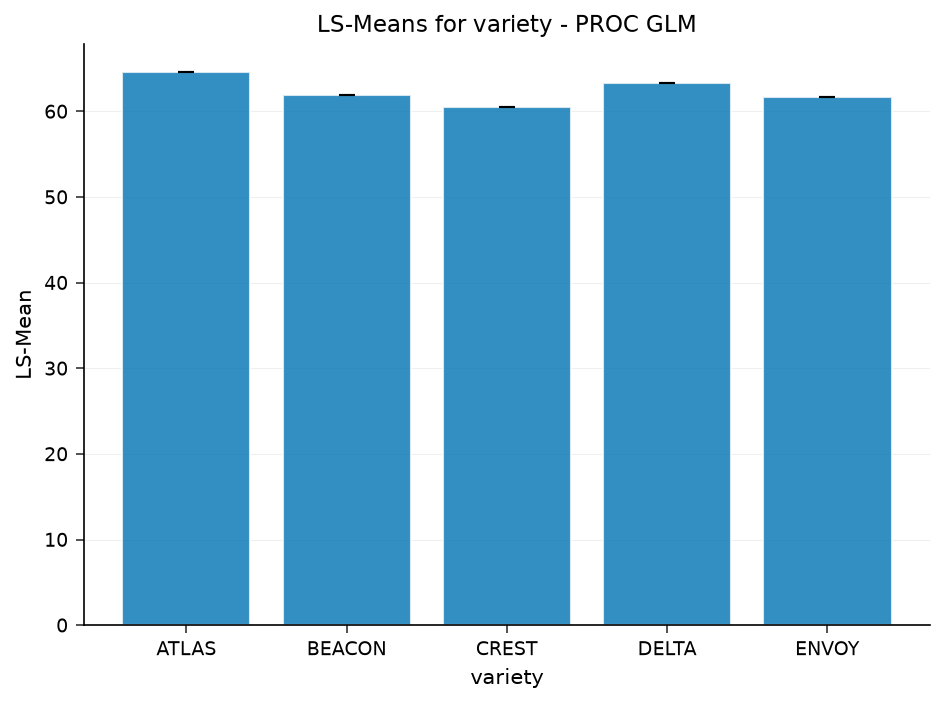

In [4]:
/* --------------------------------------------------------
   Latin square ANOVA: variety adjusted for row and column
   blocking effects
   -------------------------------------------------------- */
proc glm data=work.field_trial;
    class variety row_block col_block;
    model yield_bpa = variety row_block col_block / ss3;
    lsmeans variety / pdiff cl adjust=tukey;
    lsmeans variety / slice=row_block;
    output out=work.trial_residuals r=residual p=predicted;
run;
quit;

In [5]:
/* --------------------------------------------------------
   Normality check on residuals: Shapiro-Wilk and QQ plot
   -------------------------------------------------------- */
proc univariate data=work.trial_residuals normal;
    var residual;
    histogram residual / normal;
    qqplot residual / normal(mu=0 sigma=est);
    title 'Residual Normality Check for Latin Square Model';
run;

                                    Residual Normality Check for Latin Square Model                                     

                                                The UNIVARIATE Procedure
                                                  Variable:  residual

                                                        Moments

N                                500    Sum Weights                      500
Mean                       -0.000000    Sum Observations           -0.000000
Std Deviation               3.772297    Variance                   14.230224
Skewness                    0.093440    Kurtosis                   -0.171036
Uncorrected SS           7100.881940    Corrected SS             7100.881940
Coeff Variation                    .    Std Error Mean              0.168702

         Basic Statistical Measures          

Location             Variability             
--------  ---------  -------------  ---------
Mean      -0.000000  Std Deviation   3.772297
Median    -0.067600  

NOTE: PROC UNIVARIATE


---

### Interpretation

**Both blocking directions matter.** Row position carries a strong gradient (F = 9.31, p < .0001), and at 20 replicates the column direction is significant as well (F = 6.40, p < .0001). Neither block is inert here, so fitting both is not just defensible practice but materially improves the error estimate against which variety is judged. This is the payoff of the Latin square: it removes two orthogonal nuisance gradients simultaneously without spending extra plots.

**Variety differences are real and substantial.** The Type III variety F-test is highly significant (F = 17.45, p < .0001). The LSMEANS (adjusted for row and column) rank the varieties ATLAS 64.60, DELTA 63.38, BEACON 61.94, ENVOY 61.70, CREST 60.48 bu/ac, each with standard error 0.38. Under Tukey adjustment for the ten pairwise comparisons, the separations that clear adjusted p < 0.05 are ATLAS - BEACON (+2.66, p < .0001), ATLAS - CREST (+4.12, p < .0001), ATLAS - ENVOY (+2.90, p < .0001), CREST - DELTA (-2.89, p < .0001), and DELTA - ENVOY (+1.68, p = 0.0172). The two leaders, ATLAS and DELTA, are not distinguishable from each other (+1.23, adjusted p = 0.16), and the three lower varieties (BEACON, ENVOY, CREST) form a band that mostly does not separate internally after multiplicity control.

**The variety signal is consistent across the field.** The SLICE=row_block tests evaluate variety within each row position. Variety is significant in four of the five rows (R2, R3, R5 all p <= 0.0001; R4 p = 0.0196), and only R1 shows no detectable variety effect (p = 0.7609). A ranking that reproduces in most rows of the field, rather than being driven by one favorable strip, is what you want before recommending a variety.

**Assumptions hold.** Residuals are mean-zero with standard deviation 3.77, near-symmetric (skewness 0.09, kurtosis -0.17), and pass every normality test applied (Shapiro-Wilk p = 0.43, Kolmogorov-Smirnov p = 0.88, Anderson-Darling p = 0.15, Cramer-von Mises p = 0.90). The residual-versus-predicted and Q-Q plots show no funnel or curvature. The parametric F-tests are therefore valid.

**Bottom line.** ATLAS is the top performer, significantly outyielding BEACON, ENVOY, and CREST, with DELTA close behind and itself clearly ahead of CREST. ATLAS and DELTA cannot be separated at this sample size, so both belong on the shortlist for the region; a follow-up trial focused on the ATLAS-versus-DELTA contrast would resolve which of the two leaders to recommend.

---

In [6]:
/* --------------------------------------------------------
   Export variety performance summary for agronomists
   -------------------------------------------------------- */
proc means data=work.field_trial noprint;
    class variety;
    var yield_bpa;
    output out=work.variety_summary
        n=n_plots mean=mean_yield std=std_yield
        min=min_yield max=max_yield;
run;

proc export data=work.variety_summary
    outfile='latin_square_variety_summary.csv'
    dbms=csv replace;
run;

NOTE: PROC MEANS
NOTE: Output dataset work.variety_summary has 6 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC EXPORT data=work.variety_summary outfile=latin_square_variety_summary.csv

NOTE: Exported 6 rows to latin_square_variety_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>